# Explore the data

## Load the dataset

In [8]:
from scipy.io import wavfile
import os
import numpy as np

dataDir = "../dataset/ComParE2017_Cold_4students"
waveDir = os.path.join(dataDir, 'wav')
files = os.listdir(waveDir)

for file in files:
    if file.endswith(".wav"):
        print(file)
        sampleRate, data = wavfile.read(os.path.join(waveDir, file))
        print(sampleRate)
        print(data.shape)



devel_7835.wav
16000
(87521,)
train_2866.wav
16000
(56641,)
test_4962.wav
16000
(54721,)
devel_0182.wav
16000
(114561,)
test_8180.wav
16000
(145121,)
devel_2795.wav
16000
(71041,)
train_8393.wav
16000
(155041,)
devel_4482.wav
16000
(114241,)
train_0917.wav
16000
(54081,)
test_6813.wav
16000
(53281,)
devel_5944.wav
16000
(134081,)
devel_6295.wav
16000
(111681,)
devel_0828.wav
16000
(74081,)
devel_6281.wav
16000
(54081,)
devel_5788.wav
16000
(61921,)
train_8387.wav
16000
(105121,)
devel_4496.wav
16000
(76481,)
train_9099.wav
16000
(107201,)
test_6807.wav
16000
(64481,)
train_0903.wav
16000
(52481,)
devel_5950.wav
16000
(53601,)
test_8194.wav
16000
(69761,)
devel_2959.wav
16000
(122241,)
devel_2781.wav
16000
(52801,)
devel_1288.wav
16000
(57441,)
devel_7821.wav
16000
(104321,)
test_4976.wav
16000
(111521,)
train_2872.wav
16000
(83201,)
devel_0196.wav
16000
(73441,)
test_1826.wav
16000
(128641,)
train_7922.wav
16000
(40321,)
devel_2971.wav
16000
(97281,)
train_0095.wav
16000
(61921,)
test_

KeyboardInterrupt: 

## Load labels

In [ ]:
import os
import csv

labelDir = os.path.join(dataDir, 'lab')

idx = 0

with open(os.path.join(labelDir, 'ComParE2017_Cold.tsv'), 'r') as fd:
    rd = csv.reader(fd, delimiter="\t", quotechar='"')
    for row in rd:
        if idx == 0:
            idx += 1
            continue
        fileName = row[0]
        label = row[1]



['train_0001.wav', 'C']
['train_0002.wav', 'NC']
['train_0003.wav', 'NC']
['train_0004.wav', 'C']
['train_0005.wav', 'NC']
['train_0006.wav', 'NC']
['train_0007.wav', 'NC']
['train_0008.wav', 'C']
['train_0009.wav', 'NC']
['train_0010.wav', 'NC']
['train_0011.wav', 'NC']
['train_0012.wav', 'NC']
['train_0013.wav', 'NC']
['train_0014.wav', 'C']
['train_0015.wav', 'NC']
['train_0016.wav', 'NC']
['train_0017.wav', 'NC']
['train_0018.wav', 'NC']
['train_0019.wav', 'NC']
['train_0020.wav', 'NC']
['train_0021.wav', 'NC']
['train_0022.wav', 'NC']
['train_0023.wav', 'NC']
['train_0024.wav', 'NC']
['train_0025.wav', 'NC']
['train_0026.wav', 'NC']
['train_0027.wav', 'NC']
['train_0028.wav', 'NC']
['train_0029.wav', 'NC']
['train_0030.wav', 'NC']
['train_0031.wav', 'NC']
['train_0032.wav', 'C']
['train_0033.wav', 'NC']
['train_0034.wav', 'NC']
['train_0035.wav', 'C']
['train_0036.wav', 'C']
['train_0037.wav', 'NC']
['train_0038.wav', 'C']
['train_0039.wav', 'C']
['train_0040.wav', 'NC']
['train_0

# Check ECAPA embeddings

## Pseudo-speaker clustering diagnostics

Label-free sanity check on the ECAPA substrate, with WavLM-SV as an alternative comparator. Runs on train-split only (the clustering target) and reports:

- UMAP(2) visual
- UMAP(32) → KMeans(k=210) vs HDBSCAN: ARI / NMI (stability)
- kNN cohesion on KMeans partition (local neighborhood respect)
- silhouette on UMAP(32) for both partitions

In [1]:
from pathlib import Path
import torch

from speakers import (
    extract_wavlm, load_ecapa_matrix, load_wavlm_matrix,
    diagnose_embeddings, print_report,
)

DATA_DIR   = Path("../dataset/ComParE2017_Cold_4students")
CACHE_ROOT = Path("../cache")
ECAPA_DIR  = CACHE_ROOT / "ecapa-voxceleb"
WAVLM_DIR  = CACHE_ROOT / "wavlm-base-plus-sv"
DEVICE     = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"device: {DEVICE}")

wav_dir     = DATA_DIR / "wav"
train_paths = sorted(wav_dir.glob("train_*.wav"))
print(f"train files: {len(train_paths)}")


device: cuda
train files: 9505


## ECAPA diagnostics

In [2]:
X_ecapa, stems_ecapa = load_ecapa_matrix(train_paths, ECAPA_DIR)
print(f"ECAPA matrix: {X_ecapa.shape}")

rep_ecapa = diagnose_embeddings(X_ecapa, name="ECAPA-VoxCeleb", kmeans_k=210)
print_report(rep_ecapa)

ECAPA matrix: (9505, 192)


c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


=== ECAPA-VoxCeleb  (N=9505, dim_in=192, cluster space=umap32/32d) ===
  KMeans k=210  silhouette     : +0.9213
  HDBSCAN clusters    : 244
  HDBSCAN noise frac  : 0.020
  HDBSCAN silhouette  : +0.9181
  ARI  KMeans vs HDB  : +0.9050
  NMI  KMeans vs HDB  : +0.9751
  kNN cohesion (k=10) : 0.9943


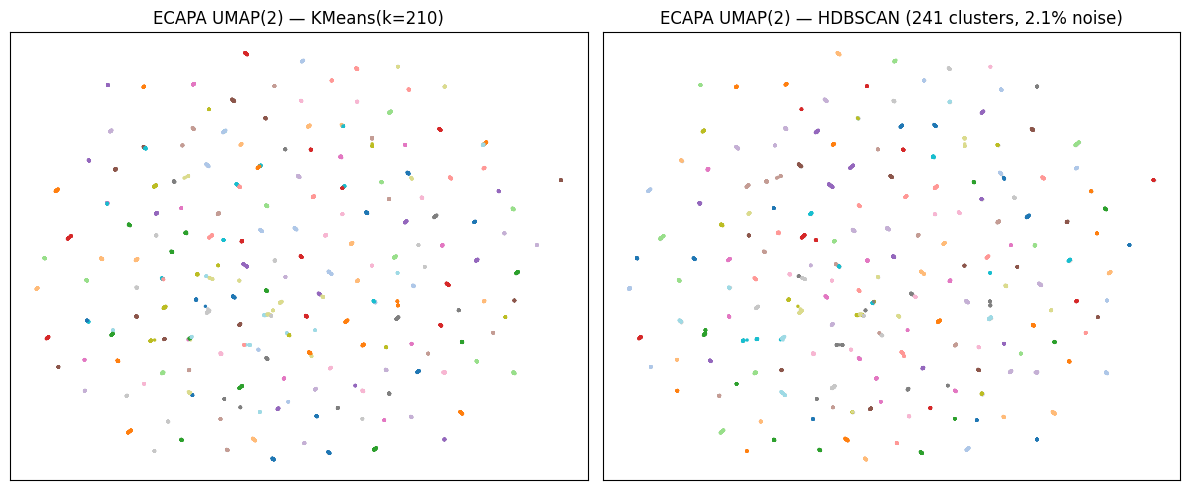

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(rep_ecapa.umap2[:, 0], rep_ecapa.umap2[:, 1], s=2, c=rep_ecapa.kmeans_labels, cmap="tab20")
ax[0].set_title(f"ECAPA UMAP(2) — KMeans(k={rep_ecapa.kmeans_k})")
ax[0].set_xticks([]); ax[0].set_yticks([])
hdb_c = rep_ecapa.hdbscan_labels
ax[1].scatter(rep_ecapa.umap2[hdb_c == -1, 0], rep_ecapa.umap2[hdb_c == -1, 1], s=2, c="lightgrey", label="noise")
ax[1].scatter(rep_ecapa.umap2[hdb_c != -1, 0], rep_ecapa.umap2[hdb_c != -1, 1], s=2, c=hdb_c[hdb_c != -1], cmap="tab20")
ax[1].set_title(f"ECAPA UMAP(2) — HDBSCAN ({rep_ecapa.hdbscan_n_clusters} clusters, {rep_ecapa.hdbscan_noise_frac:.1%} noise)")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()


## WavLM-SV diagnostics

Extracts `microsoft/wavlm-base-plus-sv` embeddings on train only (dev/test skipped until we commit). First run caches to `cache/wavlm-base-plus-sv/`.

In [3]:
n_new = extract_wavlm(
    wav_paths=train_paths,
    out_dir=WAVLM_DIR,
    device=DEVICE,
    batch_size=8,
    max_seconds=30.0,
    skip_existing=True,
    num_workers=8
)
print(f"[wavlm] newly extracted: {n_new}")


[wavlm] to_process=9505  skipped_existing=0  out=..\cache\wavlm-base-plus-sv


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/405M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/404M [00:00<?, ?B/s]

wavlm:   0%|          | 0/1189 [00:19<?, ?it/s]

c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\torch\nn\functional.py:5849: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[wavlm] newly extracted: 9505


In [4]:
X_wavlm, stems_wavlm = load_wavlm_matrix(train_paths, WAVLM_DIR)
print(f"WavLM matrix: {X_wavlm.shape}")

rep_wavlm = diagnose_embeddings(X_wavlm, name="WavLM-base-plus-sv", kmeans_k=210)
print_report(rep_wavlm)


WavLM matrix: (9505, 512)


c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


=== WavLM-base-plus-sv  (N=9505, dim_in=512, cluster space=umap32/32d) ===
  KMeans k=210  silhouette     : +0.4969
  HDBSCAN clusters    : 257
  HDBSCAN noise frac  : 0.250
  HDBSCAN silhouette  : +0.6231
  ARI  KMeans vs HDB  : +0.0930
  NMI  KMeans vs HDB  : +0.7988
  kNN cohesion (k=10) : 0.9156


In [5]:
X_ecapa, stems_ecapa = load_ecapa_matrix(train_paths, ECAPA_DIR)
print(f"ECAPA matrix: {X_ecapa.shape}")

rep_ecapa_raw = diagnose_embeddings(X_ecapa, name="ECAPA-VoxCeleb (raw)", kmeans_k=210, umap_dim=None)
print_report(rep_ecapa_raw)

ECAPA matrix: (9505, 192)


c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


=== ECAPA-VoxCeleb (raw)  (N=9505, dim_in=192, cluster space=raw-L2/192d) ===
  KMeans k=210  silhouette     : +0.2351
  HDBSCAN clusters    : 204
  HDBSCAN noise frac  : 0.027
  HDBSCAN silhouette  : +0.2905
  ARI  KMeans vs HDB  : +0.8557
  NMI  KMeans vs HDB  : +0.9620
  kNN cohesion (k=10) : 0.9574


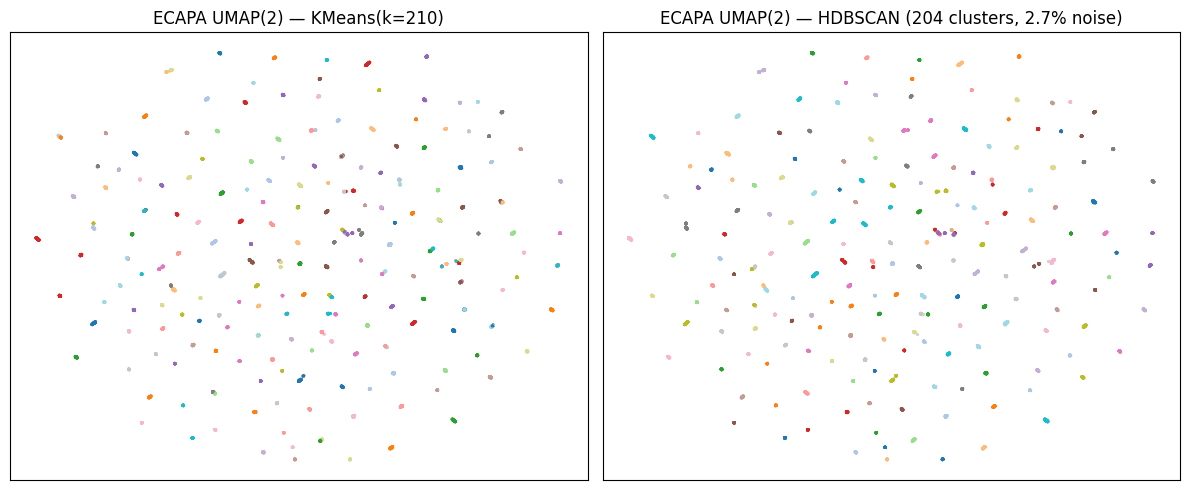

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(rep_ecapa_raw.umap2[:, 0], rep_ecapa_raw.umap2[:, 1], s=2, c=rep_ecapa_raw.kmeans_labels, cmap="tab20")
ax[0].set_title(f"ECAPA UMAP(2) — KMeans(k={rep_ecapa_raw.kmeans_k})")
ax[0].set_xticks([]); ax[0].set_yticks([])
hdb_c = rep_ecapa_raw.hdbscan_labels
ax[1].scatter(rep_ecapa_raw.umap2[hdb_c == -1, 0], rep_ecapa_raw.umap2[hdb_c == -1, 1], s=2, c="lightgrey", label="noise")
ax[1].scatter(rep_ecapa_raw.umap2[hdb_c != -1, 0], rep_ecapa_raw.umap2[hdb_c != -1, 1], s=2, c=hdb_c[hdb_c != -1], cmap="tab20")
ax[1].set_title(f"ECAPA UMAP(2) — HDBSCAN ({rep_ecapa_raw.hdbscan_n_clusters} clusters, {rep_ecapa_raw.hdbscan_noise_frac:.1%} noise)")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()


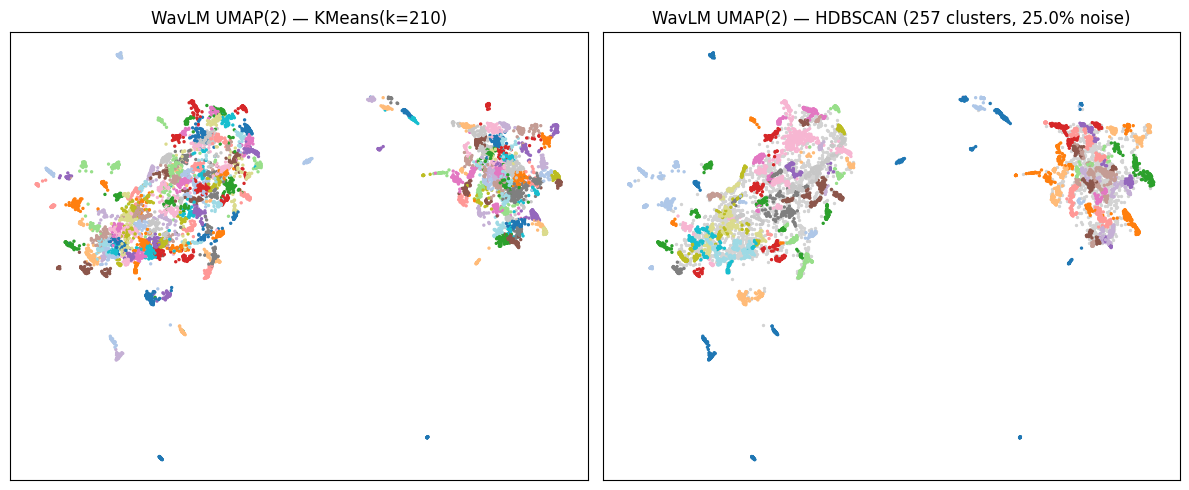

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(rep_wavlm.umap2[:, 0], rep_wavlm.umap2[:, 1], s=2, c=rep_wavlm.kmeans_labels, cmap="tab20")
ax[0].set_title(f"WavLM UMAP(2) — KMeans(k={rep_wavlm.kmeans_k})")
ax[0].set_xticks([]); ax[0].set_yticks([])
hdb_c = rep_wavlm.hdbscan_labels
ax[1].scatter(rep_wavlm.umap2[hdb_c == -1, 0], rep_wavlm.umap2[hdb_c == -1, 1], s=2, c="lightgrey", label="noise")
ax[1].scatter(rep_wavlm.umap2[hdb_c != -1, 0], rep_wavlm.umap2[hdb_c != -1, 1], s=2, c=hdb_c[hdb_c != -1], cmap="tab20")
ax[1].set_title(f"WavLM UMAP(2) — HDBSCAN ({rep_wavlm.hdbscan_n_clusters} clusters, {rep_wavlm.hdbscan_noise_frac:.1%} noise)")
ax[1].set_xticks([]); ax[1].set_yticks([])
plt.tight_layout(); plt.show()


## Side-by-side summary

In [8]:
def _row(r):
    return (
        f"{r.name:<26s} [{r.space:<7s}]  "
        f"sil_KM={r.silhouette_kmeans:+.3f}  "
        f"sil_HDB={r.silhouette_hdbscan:+.3f}  "
        f"ARI={r.ari_kmeans_vs_hdbscan:+.3f}  "
        f"NMI={r.nmi_kmeans_vs_hdbscan:+.3f}  "
        f"kNN={r.knn_cohesion_mean:.3f}  "
        f"HDB_k={r.hdbscan_n_clusters:<4d} "
        f"noise={r.hdbscan_noise_frac:.2%}"
    )

for r in [rep_ecapa, rep_ecapa_raw, rep_wavlm, rep_wavlm_raw]:
    print(_row(r))


NameError: name 'rep_wavlm_raw' is not defined